In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

#Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

from langchain_openai import ChatOpenAI


In [ ]:
class State(TypedDict):
    messages:Annotated[list,add_messages]#---> reducer

llm=ChatOpenAI(
    model="qwen/qwen3-4b-2507",
    base_url="http://127.0.0.1:1234/v1",
    api_key="dummy",
    temperature=0.7
)

AIMessage(content="I don't have access to real-time information or a token counter that tracks how many tokens are left in your session. The number of tokens available depends on your specific usage, model limits, and platform (like OpenAI, Anthropic, etc.).\n\nIf you're using a service like OpenAI, for example:\n- GPT-3.5 Turbo has a limit of around 4,096 tokens per message.\n- GPT-4 has a limit of up to 8,192 tokens.\n\nTo check how many tokens are left in your current session:\n1. Look at the platform or interface you're using (e.g., OpenAI's API dashboard, a chat app, etc.).\n2. Check for a token count or usage tracker in the interface.\n3. If you're using an API, you can calculate tokens using the token counting tool provided by the service.\n\nLet me know which platform or service you're using, and I can guide you further! 😊", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 203, 'prompt_tokens': 13, 'total_tokens': 216, 'completion_tok

In [6]:
def superbot(state:State):
    return {
        "messages":[llm.invoke(state["messages"])]
    }

graph=StateGraph(State)

graph.add_node("superbot",superbot)


graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

app=graph.compile()



In [20]:
while True:
    question = input("Enter Your Query: ")

    if question.lower() == "exit":
        break

    for message, metadata in app.stream(
        {
            "messages": [
                {
                    "role": "user",
                    "content": question
                }
            ]
        },
        stream_mode="messages"
    ):
        if message.content:
            print(message.content, end="", flush=True)

    print()

Hi Niko! 😊 How's it going? I'm glad to meet you! What's on your mind today? 🚀
Sure! Below is a complete, ready-to-run Python code using **Scikit-learn** to build a machine learning model — specifically, a **Random Forest Classifier** — on the **Iris dataset**. The code includes:

1. Data loading and exploration  
2. Model training and evaluation  
3. Visualizations (bar plots, confusion matrix, feature importance)  
4. An **interactive graph** using `Plotly` (for dynamic exploration)

---

### ✅ Requirements
Make sure you have the following installed:
```bash
pip install scikit-learn matplotlib seaborn plotly pandas numpy
```

---

### 🚀 Full Code (with Visuals & Interactive Plot)

```python
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accur

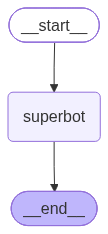

In [8]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))